In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Set plotting style
sns.set(style="whitegrid")

In [4]:
# Configuration
data_path = "data/"
prediction_date = pd.to_datetime("2025-06-18")

In [5]:
def load_data():
    print("Loading datasets...")
    customers = pd.read_csv(os.path.join(data_path, "customers.csv"))
    transactions = pd.read_csv(os.path.join(data_path, "transactions.csv"))
    churn_labels = pd.read_csv(os.path.join(data_path, "churn_labels.csv"))
    clv_labels = pd.read_csv(os.path.join(data_path, "clv_labels.csv"))
    support_tickets = pd.read_csv(os.path.join(data_path, "support_tickets.csv"))
    events = pd.read_csv(os.path.join(data_path, "events.csv"))
    return customers, transactions, churn_labels, clv_labels, support_tickets, events

In [6]:
def clean_and_prepare(customers, transactions, churn_labels, clv_labels, support_tickets, events):
    print("Cleaning and preparing all datasets...")

    # 1. Handle Missing Values & Duplicates
    customers = customers.dropna().drop_duplicates()
    transactions = transactions.dropna().drop_duplicates()
    churn_labels = churn_labels.dropna().drop_duplicates()
    clv_labels = clv_labels.dropna().drop_duplicates()
    support_tickets = support_tickets.dropna().drop_duplicates()
    events = events.dropna().drop_duplicates()

    # 2. Handle Inconsistencies
    customers.loc[customers['age'] < 0, 'age'] = customers['age'].median()
    transactions = transactions[transactions['amount'] >= 0]

    # 3. Handle Dates
    customers['signup_date'] = pd.to_datetime(customers['signup_date'])
    transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
    support_tickets['ticket_date'] = pd.to_datetime(support_tickets['ticket_date'])
    events['event_date'] = pd.to_datetime(events['event_date'])

    return customers, transactions, churn_labels, clv_labels, support_tickets, events


In [7]:
def perform_eda(customers, transactions, churn_labels, clv_labels, support_tickets, events):
    print("\n--- EDA & Key Factors ---")

    # Merge for analysis
    df = customers.merge(churn_labels, on='customer_id', how='inner')
    df = df.merge(clv_labels, on='customer_id', how='inner')

    # Basic transaction agg for factor identification
    trans_agg = transactions.groupby('customer_id')['amount'].agg(['sum', 'count']).rename(columns={'sum': 'total_spend', 'count': 'trans_count'})
    df = df.merge(trans_agg, on='customer_id', how='left').fillna(0)

    # Identify factors
    numeric_df = df.select_dtypes(include=[np.number])
    churn_corr = numeric_df.corr()['churn_30d'].sort_values(ascending=False)
    clv_corr = numeric_df.corr()['clv'].sort_values(ascending=False)

    print("\nFactors correlated with Churn:")
    print(churn_corr.head(5))

    print("\nFactors correlated with CLV:")
    print(clv_corr.head(5))

    # Visualization: Distribution of CLV
    plt.figure(figsize=(10, 5))
    sns.histplot(df['clv'], bins=30, kde=True)
    plt.title("Distribution of Customer Lifetime Value")
    plt.savefig("clv_distribution.png")

    return df

In [8]:
def feature_engineering(customers, transactions, support_tickets, events):
    print("\n---Feature Engineering ---")

    # 1. Tenure
    customers['tenure_days'] = (prediction_date - customers['signup_date']).dt.days

    # 2. RFM
    # Exclude refunds for monetary calculation (Note 6)
    monetary_df = transactions[transactions['is_refund'] == 0]

    rfm = transactions.groupby('customer_id').agg(
        recency=('transaction_date', lambda x: (prediction_date - x.max()).days),
        frequency=('customer_id', 'count'),
    )
    monetary = monetary_df.groupby('customer_id').agg(monetary=('amount', 'sum'))
    rfm = rfm.join(monetary, how='left').fillna(0)

    # 3. Support Features
    support_feats = support_tickets.groupby('customer_id').agg(
        total_tickets=('ticket_id', 'count'),
        avg_resolution_hrs=('resolution_time_hrs', 'mean'),
        avg_satisfaction=('satisfaction_score', 'mean')
    ).fillna(0)

    # 4. Engagement (Events)
    event_counts = events.pivot_table(index='customer_id', columns='event_type', aggfunc='size', fill_value=0)
    event_counts.columns = [f'event_{col}_count' for col in event_counts.columns]
    active_days = events.groupby('customer_id')['event_date'].nunique().rename('active_days_count')

    # Merge Features
    df_feat = customers.merge(rfm, on='customer_id', how='left')
    df_feat = df_feat.merge(support_feats, on='customer_id', how='left')
    df_feat = df_feat.merge(event_counts, on='customer_id', how='left')
    df_feat = df_feat.merge(active_days, on='customer_id', how='left')
    df_feat = df_feat.fillna(0)

    # Encode
    le = LabelEncoder()
    df_feat['gender_enc'] = le.fit_transform(df_feat['gender'])
    df_feat['plan_enc'] = le.fit_transform(df_feat['plan_type'])
    df_feat['country_enc'] = le.fit_transform(df_feat['country'])

    return df_feat

In [9]:
def run_modeling(df_full):
    print("\n---Modeling ---")

    # Drop IDs and strings
    X = df_full.drop(columns=['customer_id', 'signup_date', 'gender', 'country', 'plan_type', 'churn_30d', 'clv'])

    # A. CLV Prediction
    print("Training CLV Regression...")
    y_clv = df_full['clv']
    X_train, X_test, y_train, y_test = train_test_split(X, y_clv, test_size=0.2, random_state=42)
    rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_reg.fit(X_train, y_train)
    y_pred = rf_reg.predict(X_test)
    print(f"CLV R2 Score: {r2_score(y_test, y_pred):.4f}")

    # B. Churn Prediction
    print("Training Churn Classification...")
    y_churn = df_full['churn_30d']
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_churn, test_size=0.2, random_state=42, stratify=y_churn)
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_clf.fit(X_train_c, y_train_c)
    y_pred_c = rf_clf.predict(X_test_c)
    print("Churn Report:")
    print(classification_report(y_test_c, y_pred_c))

    return rf_reg, rf_clf, X.columns

In [ ]:
def generate_insights(df, rf_reg, rf_clf, feature_names):
    print("\n---Insights & Recommendations ---")

    # Importance
    churn_imp = pd.Series(rf_clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("\nTop Predictors of Churn:")
    print(churn_imp.head(5))

    # Save Feature Importance Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=churn_imp.head(10).values, y=churn_imp.head(10).index)
    plt.title("Top 10 Features Influencing Churn")
    plt.savefig("churn_importance.png")

    print("\nRecommendations:")
    print("1. Target customers with high recency and low active days for retention campaigns.")
    print("2. Focus on improving satisfaction scores for customers with multiple support tickets.")
    print("3. Reward high-monetary customers to increase overall CLV.")

In [11]:
def perform_clustering(df):
    print("\n---Customer Segmentation ---")

    # 1. Select features for clustering (RFM + Engagement)
    cluster_cols = ['recency', 'frequency', 'monetary', 'active_days_count']
    X = df[cluster_cols]

    # 2. Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. Apply K-Means
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)

    # 4. Analyze Segments
    segment_analysis = df.groupby('cluster').agg({
        'clv': 'mean',
        'churn_30d': 'mean',
        'monetary': 'mean',
        'frequency': 'mean',
        'recency': 'mean',
        'customer_id': 'count'
    }).rename(columns={'customer_id': 'customer_count', 'churn_30d': 'churn_rate'})

    print("\nSegment Analysis Summary:")
    print(segment_analysis)

    # 5. Visualization: CLV vs Churn Rate by Segment
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=segment_analysis, x='clv', y='churn_rate', size='customer_count', hue=segment_analysis.index, palette='viridis', sizes=(100, 1000))
    plt.title("Customer Segments: CLV vs Churn Rate")
    plt.xlabel("Average CLV")
    plt.ylabel("Churn Rate")
    plt.savefig("customer_segments.png")
    print("\nSegmentation plot saved as customer_segments.png")

    return df

In [12]:
c, t, ch, cl, s, e = load_data()

Loading datasets...


In [13]:
c, t, ch, cl, s, e = clean_and_prepare(c, t, ch, cl, s, e)

Cleaning and preparing all datasets...



--- EDA & Key Factors ---

Factors correlated with Churn:
churn_30d      1.000000
clv            0.034723
customer_id    0.005210
monthly_fee    0.003712
age           -0.016059
Name: churn_30d, dtype: float64

Factors correlated with CLV:
clv            1.000000
churn_30d      0.034723
customer_id    0.020364
age            0.019857
trans_count    0.014480
Name: clv, dtype: float64


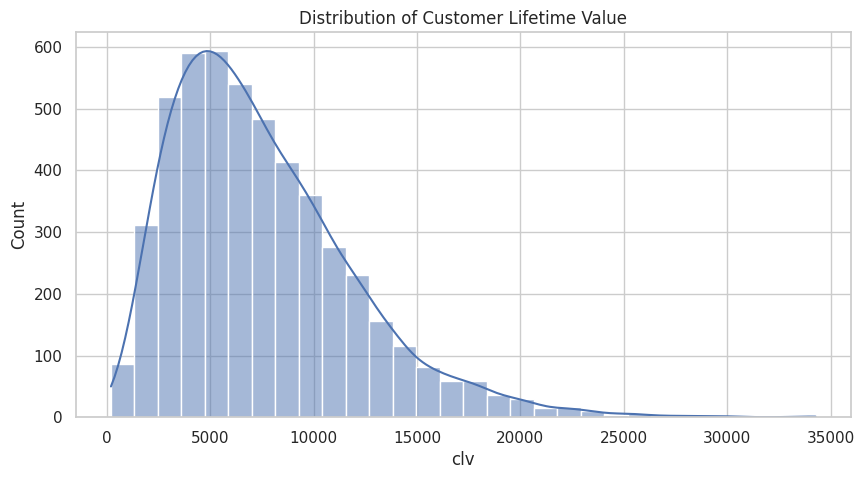

In [14]:
df_eda = perform_eda(c, t, ch, cl, s, e)

In [15]:
df_feat = feature_engineering(c, t, s, e)



---Feature Engineering ---


In [16]:
df_full = df_feat.merge(ch, on='customer_id', how='inner')
df_full = df_full.merge(cl, on='customer_id', how='inner')


In [17]:
rf_reg, rf_clf, feat_names = run_modeling(df_full)


---Modeling ---
Training CLV Regression...
CLV R2 Score: -0.0633
Training Churn Classification...
Churn Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.89       794
           1       0.00      0.00      0.00       206

    accuracy                           0.79      1000
   macro avg       0.40      0.50      0.44      1000
weighted avg       0.63      0.79      0.70      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



---Insights & Recommendations ---

Top Predictors of Churn:
monetary              0.100404
tenure_days           0.098318
recency               0.091561
avg_resolution_hrs    0.087114
age                   0.080903
dtype: float64

Recommendations:
1. Target customers with high recency and low active days for retention campaigns.
2. Focus on improving satisfaction scores for customers with multiple support tickets.
3. Reward high-monetary customers to increase overall CLV.


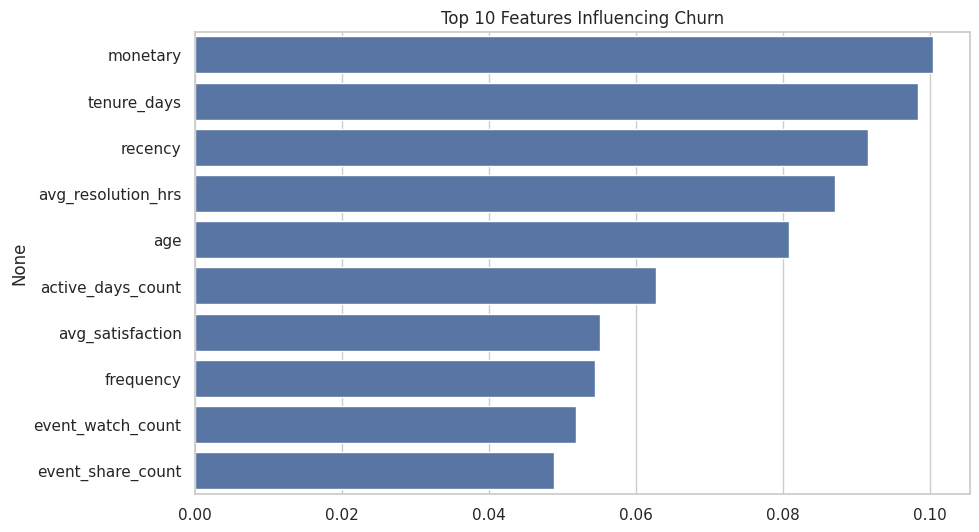

In [18]:
generate_insights(df_full, rf_reg, rf_clf, feat_names)


---Customer Segmentation ---

Segment Analysis Summary:
                 clv  churn_rate      monetary  frequency     recency  \
cluster                                                                 
0        7270.547534    0.208270   6366.883277   6.989280  270.330781   
1        7562.758477    0.215424   7507.647259   8.464627   67.108987   
2        7514.917190    0.214967   8843.904395   9.566398   67.841526   
3        7716.281845    0.187279  13806.362968  13.509541   59.694700   

         customer_count  
cluster                  
0                   653  
1                  1569  
2                  1363  
3                  1415  

Segmentation plot saved as customer_segments.png


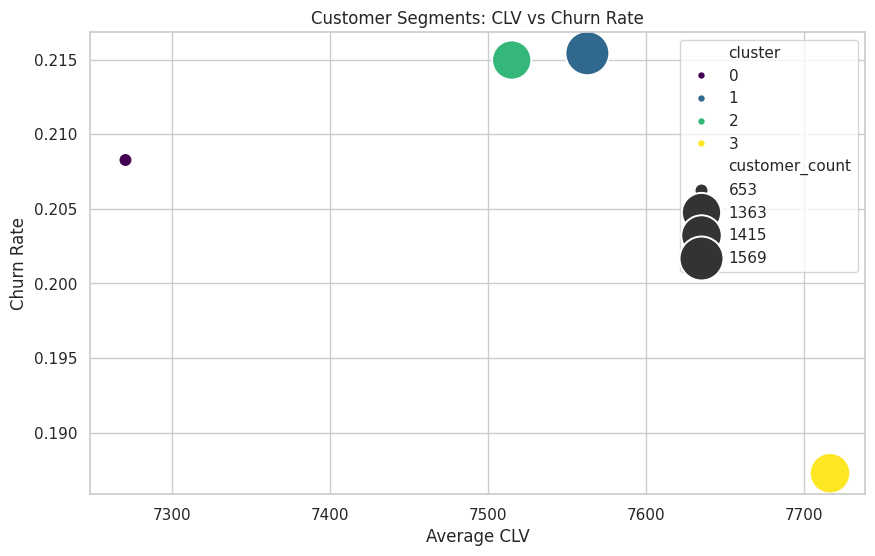

In [19]:
df_full = perform_clustering(df_full)